In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/dataset_rottenvsfresh.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
data_dir = '/content/dataset/Fruit And Vegetable Diseases Dataset'
print(os.listdir(data_dir))

['apple__rotten', 'orange__fresh', 'banana__rotten', 'orange__rotten', 'apple__fresh', 'banana__fresh']


In [ ]:
classes = sorted(os.listdir(data_dir))
print("Classes:", classes)

for cls in classes:
    print(f"{cls}: {len(os.listdir(os.path.join(data_dir, cls)))}")

Classes: ['apple__fresh', 'apple__rotten', 'banana__fresh', 'banana__rotten', 'orange__fresh', 'orange__rotten']
apple__fresh: 2438
apple__rotten: 2930
banana__fresh: 2000
banana__rotten: 2800
orange__fresh: 2075
orange__rotten: 2186


EDA

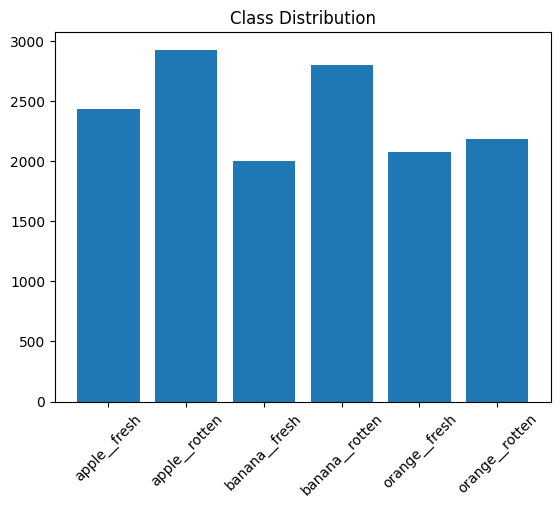

In [ ]:
# check class distribution
import matplotlib.pyplot as plt

class_counts = {}
for cls in classes:
    class_counts[cls] = len(os.listdir(os.path.join(data_dir, cls)))

plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

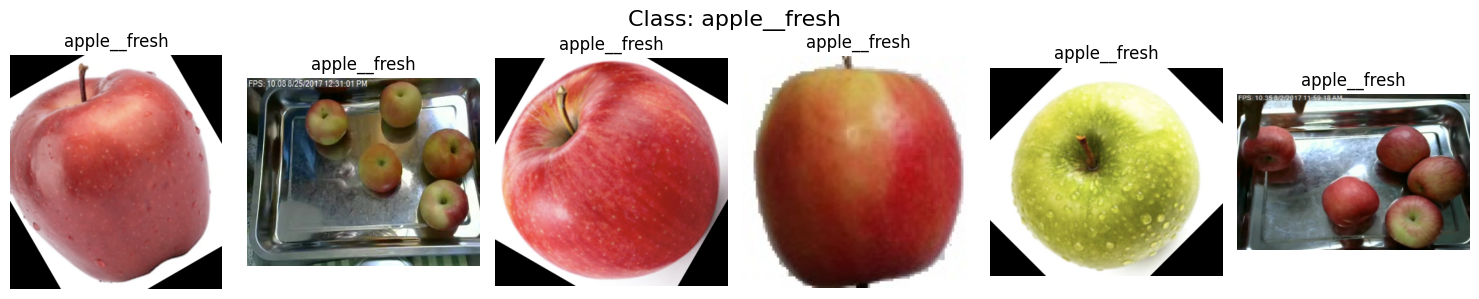

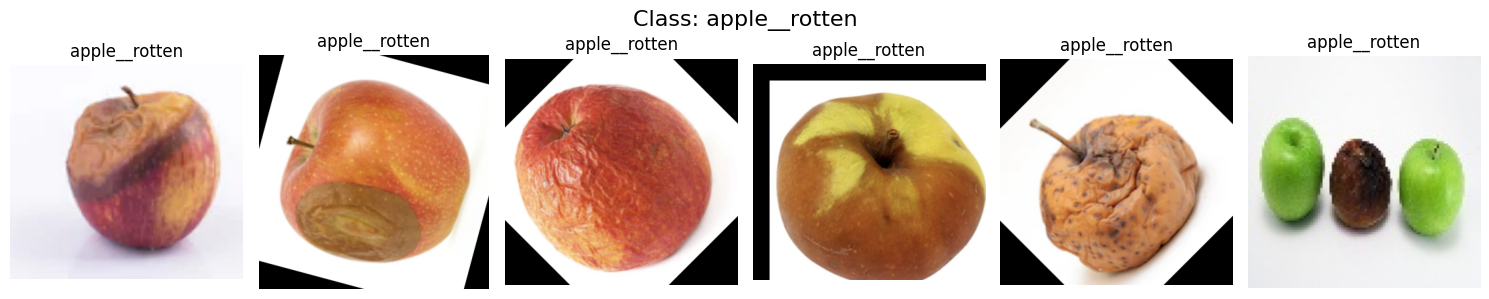

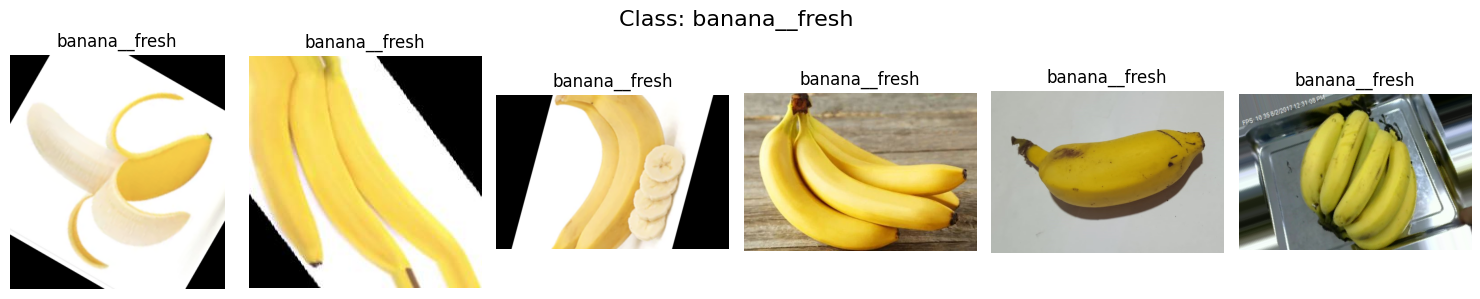

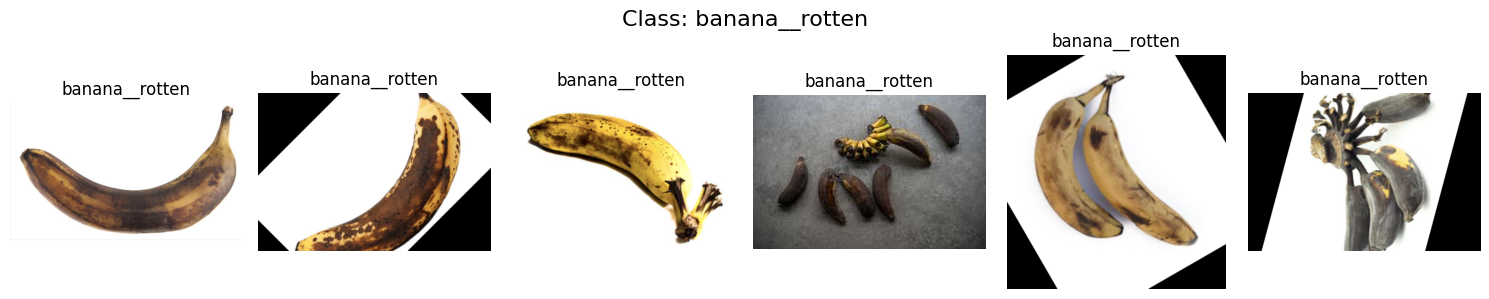

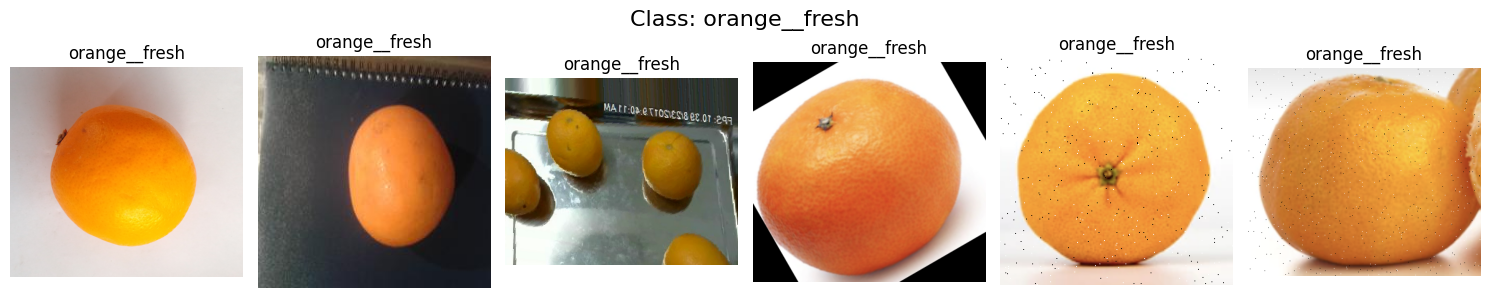

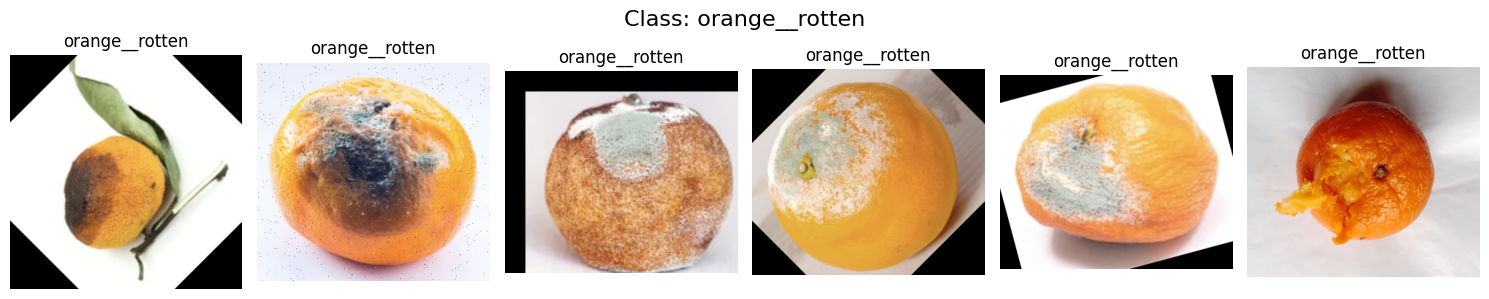

In [ ]:
# check sample images
import random
from PIL import Image

for cls in classes:
    plt.figure(figsize=(15, 3))
    plt.suptitle(f"Class: {cls}", fontsize=16)

    images = os.listdir(os.path.join(data_dir, cls))
    sample_images = random.sample(images, min(6, len(images)))

    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(data_dir, cls, img_name)
        img = Image.open(img_path)

        plt.subplot(1, 6, i + 1)
        plt.imshow(img)
        plt.title(f"{cls}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Preprocessing

In [ ]:
!pip install imagehash

In [12]:
# check duplicates
import imagehash

hashes = {}
duplicates = []

for cls in classes:
    for img_name in os.listdir(os.path.join(data_dir, cls)):
        path = os.path.join(data_dir, cls, img_name)
        try:
            img = Image.open(path)
            h = imagehash.average_hash(img)

            if h in hashes:
                duplicates.append((path, hashes[h]))
            else:
                hashes[h] = path
        except:
            continue

print("Duplicates:", len(duplicates))

Duplicates: 1468


In [13]:
# remove duplicates
for dup, original in duplicates:
    try:
        os.remove(dup)
    except:
        pass

In [14]:
# recheck duplicates
hashes = {}
duplicates = []

for cls in classes:
    for img_name in os.listdir(os.path.join(data_dir, cls)):
        path = os.path.join(data_dir, cls, img_name)
        try:
            img = Image.open(path)
            h = imagehash.average_hash(img)

            if h in hashes:
                duplicates.append((path, hashes[h]))
            else:
                hashes[h] = path
        except:
            continue

print("Duplicates:", len(duplicates))

Duplicates: 0


In [ ]:
# remove broken images
corrupted_count = 0

for cls in os.listdir(data_dir):
    cls_path = os.path.join(data_dir, cls)

    if not os.path.isdir(cls_path):
        continue

    for img_name in os.listdir(cls_path):
        path = os.path.join(cls_path, img_name)

        try:
            with Image.open(path) as img:
                img.verify()
        except:
            os.remove(path)
            corrupted_count += 1

print(f"Removed images: {corrupted_count}")

Removed images: 0


In [ ]:
# remove blurry images (<100x100)
removed_count = 0
min_size = 100

for cls in os.listdir(data_dir):
    cls_path = os.path.join(data_dir, cls)

    if not os.path.isdir(cls_path):
        continue

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            with Image.open(img_path) as img:
                width, height = img.size

            if width < min_size or height < min_size:
                os.remove(img_path)
                removed_count += 1

        except:
            os.remove(img_path)
            removed_count += 1

print(f"Removed images: {removed_count}")

Removed images: 0


In [15]:
# recheck class balance
for cls in classes:
    print(f"{cls}: {len(os.listdir(os.path.join(data_dir, cls)))}")

apple__fresh: 2202
apple__rotten: 2455
banana__fresh: 1853
banana__rotten: 2596
orange__fresh: 1875
orange__rotten: 1980


In [16]:
# splitting
from sklearn.model_selection import train_test_split
import os, shutil

base_dir = '/content/processed'

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

os.makedirs(base_dir, exist_ok=True)
classes = os.listdir(data_dir)

for cls in classes:
    os.makedirs(os.path.join(base_dir, 'train', cls), exist_ok=True)
    os.makedirs(os.path.join(base_dir, 'test', cls), exist_ok=True)
    os.makedirs(os.path.join(base_dir, 'val', cls), exist_ok=True)

    images = os.listdir(os.path.join(data_dir, cls))

    train, temp = train_test_split(images, test_size=0.2, random_state=42)
    test, val = train_test_split(temp, test_size=0.5, random_state=42)

    for img in train:
        shutil.copy(os.path.join(data_dir, cls, img),
                    os.path.join(base_dir, 'train', cls, img))

    for img in test:
        shutil.copy(os.path.join(data_dir, cls, img),
                    os.path.join(base_dir, 'test', cls, img))

    for img in val:
        shutil.copy(os.path.join(data_dir, cls, img),
                    os.path.join(base_dir, 'val', cls, img))

In [17]:
def count_split_data(base_dir):
    splits = ['train', 'test', 'val']

    for split in splits:
        print(f"\n{split.upper()}:")

        split_path = os.path.join(base_dir, split)

        for cls in os.listdir(split_path):
            cls_path = os.path.join(split_path, cls)
            count = len(os.listdir(cls_path))
            print(f"{cls}: {count}")

count_split_data('/content/processed')


TRAIN:
apple__rotten: 1964
orange__fresh: 1500
banana__rotten: 2076
orange__rotten: 1584
apple__fresh: 1761
banana__fresh: 1482

TEST:
apple__rotten: 245
orange__fresh: 187
banana__rotten: 260
orange__rotten: 198
apple__fresh: 220
banana__fresh: 185

VAL:
apple__rotten: 246
orange__fresh: 188
banana__rotten: 260
orange__rotten: 198
apple__fresh: 221
banana__fresh: 186


In [18]:
# preprocessing split data and augmentation
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    '/content/processed/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_test_gen.flow_from_directory(
    '/content/processed/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_data = val_test_gen.flow_from_directory(
    '/content/processed/test',
    target_size=(224, 224),
    batch_size=32,
    shuffle=False,
    class_mode='categorical'
)

Found 10360 images belonging to 6 classes.
Found 1299 images belonging to 6 classes.
Found 1293 images belonging to 6 classes.


Modelling

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 468s 1s/step - accuracy: 0.9076 - loss: 0.2539 - val_accuracy: 0.9731 - val_loss: 0.0896
Epoch 2/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 465s 1s/step - accuracy: 0.9567 - loss: 0.1184 - val_accuracy: 0.9684 - val_loss: 0.0832
Epoch 3/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 491s 2s/step - accuracy: 0.9700 - loss: 0.0835 - val_accuracy: 0.9823 - val_loss: 0.0496
Epoch 4/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 474s 1s/step - accuracy: 0.9751 - loss: 0.0673 - val_accuracy: 0.9769 - val_loss: 0.0553
Epoch 5/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 479s 1s/step - accuracy: 0.9795 - loss: 0.0543 - val_accuracy: 0.9869 - val_loss: 0.0451
Epoch 6/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 484s 1s/step - accuracy: 0.9861 - loss: 0.0425 - val_accuracy: 0.9900 - val_loss: 0.0276
Epoch 7/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 465s 1s/step - accuracy: 0.9858 - loss: 0.0399 - val_accuracy: 0.9869 - val_loss: 0.0315
Epoch 8/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 464s 1s/step - accuracy: 0.9868 - loss: 0.0379 - val_accu

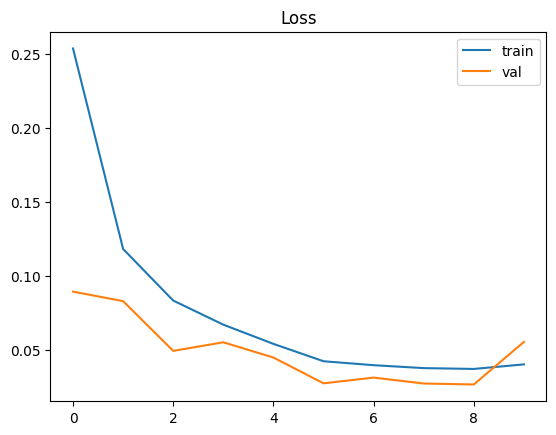

In [ ]:
# loss plot
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

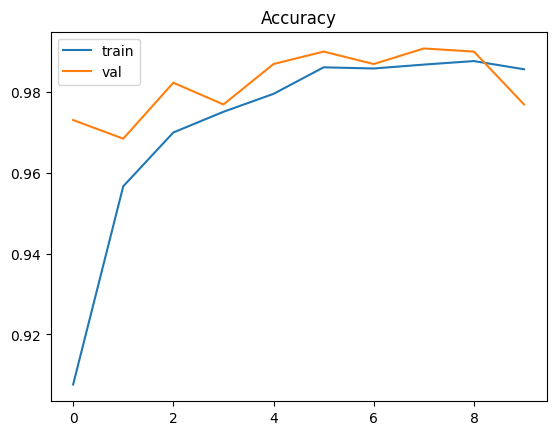

In [ ]:
# accuracy plot
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

In [ ]:
class_names = list(test_data.class_indices.keys())

In [ ]:
# classification report
from sklearn.metrics import classification_report
import numpy as np

predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(test_data.classes, y_pred, target_names=class_names))

41/41 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step
                precision    recall  f1-score   support

  apple__fresh       0.99      0.97      0.98       216
 apple__rotten       0.94      1.00      0.97       245
 banana__fresh       0.99      0.99      0.99       185
banana__rotten       0.99      1.00      0.99       260
 orange__fresh       0.99      0.99      0.99       187
orange__rotten       1.00      0.95      0.97       201

      accuracy                           0.98      1294
     macro avg       0.99      0.98      0.98      1294
  weighted avg       0.98      0.98      0.98      1294



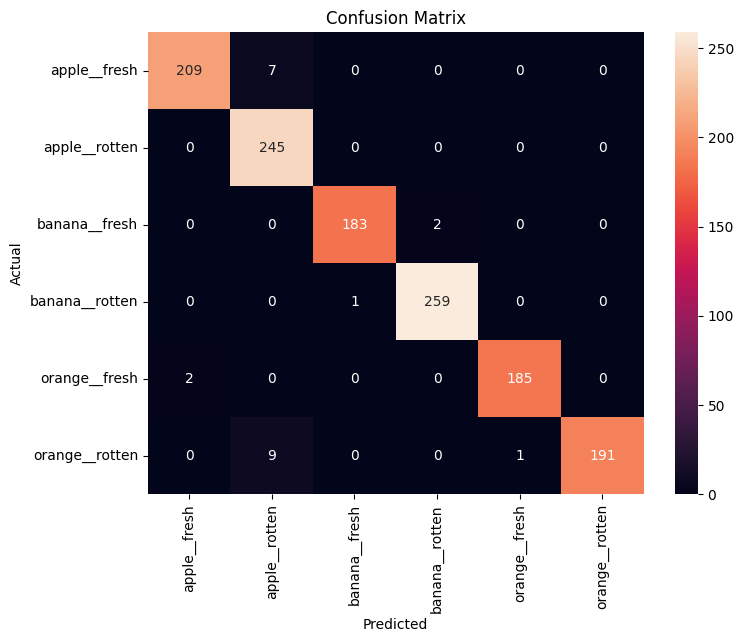

In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Testing on random data

In [ ]:
import time
from tensorflow.keras.preprocessing import image

img_path = '/content/test_image.jpg'

# random_class = random.choice(os.listdir('/content/processed/test'))
# random_image = random.choice(os.listdir(f'/content/processed/test/{random_class}'))

# img_path = f'/content/processed/test/{random_class}/{random_image}'

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
start_time = time.time()

predictions = model.predict(img_array)

end_time = time.time()
inference_time = end_time - start_time

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


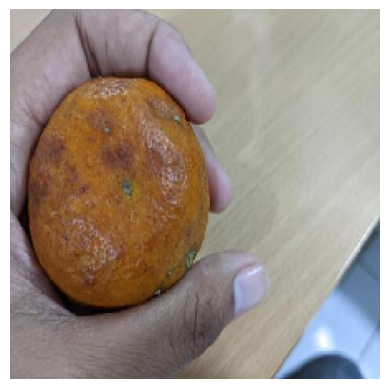

Actual: apple__fresh
apple__fresh: 0.00%
apple__rotten: 13.89%
banana__fresh: 0.00%
banana__rotten: 0.00%
orange__fresh: 0.00%
orange__rotten: 86.11%

Inference time: 0.1330 sec


In [ ]:
class_names = sorted(
    test_data.class_indices,
    key=test_data.class_indices.get
)

probs = predictions[0]

plt.imshow(img)
plt.axis('off')
plt.show()
print("Actual:", random_class)
for i, prob in enumerate(probs):
    print(f"{class_names[i]}: {prob*100:.2f}%")
print(f"\nInference time: {inference_time:.4f} sec")

Download

In [ ]:
model.save('/content/drive/MyDrive/rottenvsfresh_model.h5')

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('fruit_model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpx0hznh25'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137376410135312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137376410135504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137376410138000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137376410137616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137376410136464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137376410138192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137376410136656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137376410138768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137376410138384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137376410136272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1373764101